### Modeling Inflation Using VAR: A Survey Between Conventional and ML-based Approaches

The objective of this study is to rigorously evaluate the impact of machine learning-based feature selection on the forecast performance of vector autoregressive (VAR) models. Specifically, the analysis investigates whether covariate selection via Lasso regression and the XGBoost algorithm can improve the in-sample predictive accuracy of VAR models relative to conventional specification methods. The empirical application utilizes a high-dimensional macroeconomic dataset of U.S. indicators curated by Michael McCracken and Serena Ng, accessible at: https://research.stlouisfed.org/econ/mccracken/fred-databases. Forecasting performance is assessed for the Consumer Price Index (CPI) under three model configurations:

- A benchmark VAR with predictors chosen based on established macroeconomic theory and prior empirical literature;
- A sparse VAR in which relevant variables are selected through Lasso penalization;
- A data-driven VAR with features identified via the gradient-boosted decision tree framework implemented in XGBoost.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import pandas as pd 
import seaborn as sns
sns.set()
import datetime as dt
import warnings
warnings.simplefilter('ignore')

from sklearn import (linear_model, metrics, neural_network, pipeline, preprocessing, model_selection)
import statsmodels.formula.api as sm

!pip install xgboost
from xgboost import XGBRegressor, plot_importance



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


#### Data visualization and exploration

Initially we conduct exploratory data analysis (EDA) on a subset of macroeconomic time series to inform the preliminary screening and identification of candidate variables for inclusion in the vector autoregressive (VAR) model specification.

In [2]:
from pathlib import Path

def resolve_fredmd_path():
    candidate_paths = [
        Path.cwd() / "data" / "fredmd.csv",
        Path.cwd() / "fredmd.csv",
        Path.cwd().parent / "data" / "fredmd.csv",
    ]
    fred_path = next((p for p in candidate_paths if p.exists()), None)
    if fred_path is None:
        raise FileNotFoundError("Could not locate fredmd.csv. Expected one of: data/fredmd.csv or fredmd.csv")
    return fred_path

# Some cleaning
fred = pd.read_csv(resolve_fredmd_path())

fred = fred.drop(0)
fred["sasdate"] = pd.to_datetime(fred["sasdate"])
fred = fred.rename(columns={"sasdate": "date"})
fred = fred.set_index("date").sort_index()

# Stationarity in yearly percentage change
for c in list(fred.columns.values):
    fred[c + "_diff"] = (fred[c] - fred[c].shift(12))/fred[c].shift(12) * 100

fred.head()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA_diff,DSERRG3M086SBEA_diff,CES0600000008_diff,CES2000000008_diff,CES3000000008_diff,UMCSENTx_diff,DTCOLNVHFNM_diff,DTCTHFNM_diff,INVEST_diff,VIXCLSx_diff
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2442.158,2293.2,17.272,292266.4261,18235.77392,22.0151,23.3984,22.2848,31.5847,18.6861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-02-01,2451.778,2301.5,17.452,294424.7425,18369.56308,22.4463,23.7142,22.4778,31.8164,18.7842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-03-01,2467.594,2318.5,17.617,293418.6704,18523.05762,22.7696,23.8577,22.5882,31.8164,19.1520,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-04-01,2483.671,2334.9,17.553,299322.8039,18534.46600,23.2547,24.2022,22.9191,32.3184,19.2746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-05-01,2498.026,2350.4,17.765,301364.3249,18679.66354,23.6050,24.4032,23.1398,32.4728,19.6670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Out of analytical interest and to align with established economic theory, the historical relationships between inflation and key macro-financial variables—such as the unemployment rate, federal funds rate, and stock market indicators—are explored to evaluate their potential usefulness as predictors in modeling inflation dynamics.

In [3]:
def scatter_plot(data, col_1, col_2, color):
    
    """
    Creates scatter plots for inflation, unemployment rate, Fed Funds rate, the S&P500 Composite Index
    """
    
    fig, ax = plt.subplots(figsize=(10,4))
    
    ax.scatter(x=data[col_1], y=data[col_2], alpha=0.4, color=color)
    ax.set_xlabel("Inflation", fontname="Verdana")
    
    if col_2 == "UNRATE":
        ax.set_title("Inflation and unemployment rate", fontsize=16, fontname="Verdana", loc="left")
        ax.set_ylabel("Unemployment rate", fontname="Verdana")
    elif col_2 == "S&P 500":
        ax.set_title("Inflation and S&P500", fontsize=16, fontname="Verdana", loc="left")
        ax.set_ylabel("S&P500", fontname="Verdana")
    else:
        ax.set_title("Inflation and Fed Funds rate", fontsize=16, fontname="Verdana", loc="left")
        ax.set_ylabel("Fed Funds rate", fontname="Verdana")


The Phillips Curve is frequently cited in the economics literature as evidence of a trade-off between inflation and unemployment. To assess whether this empirical relationship holds in the data, the correlation between these two variables is examined. Additionally, the potential predictive content of stock market indicators—in particular, the S&P 500 Composite Index—for future inflation is explored, motivated by the hypothesis that equity markets may incorporate forward-looking information about macroeconomic conditions. Lastly, since the Federal Reserve targets inflation by adjusting short-term interest rates, the federal funds rate is analyzed to determine whether it possesses explanatory or predictive power for inflation dynamics.

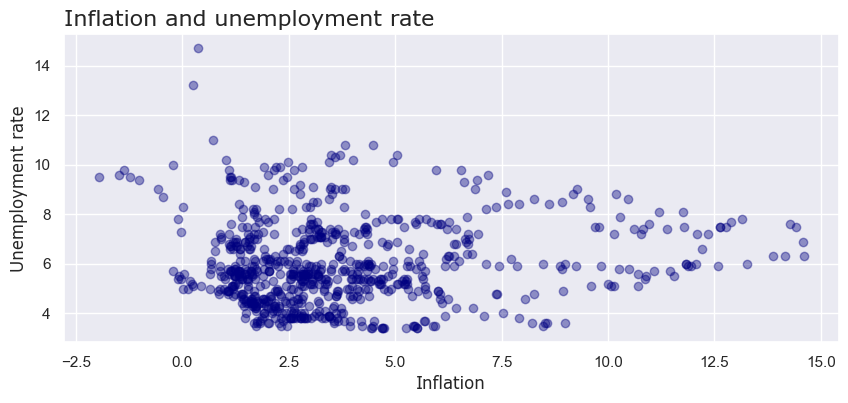

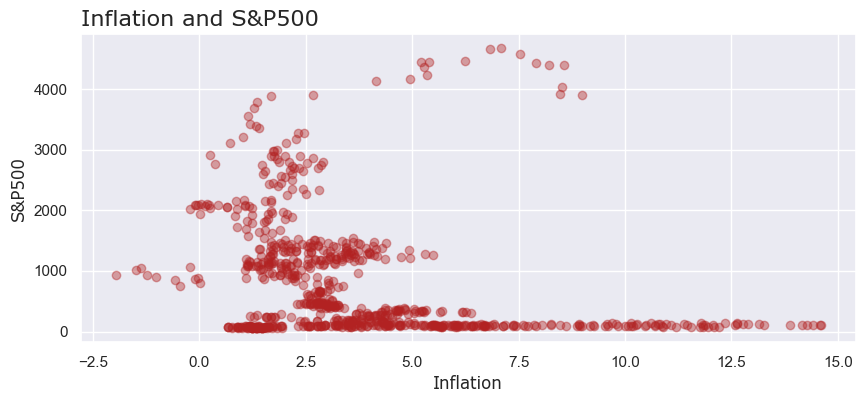

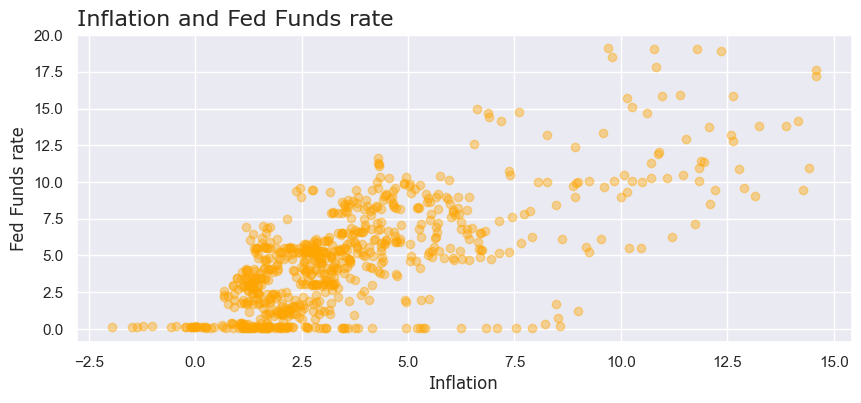

In [4]:
for f,c in dict(zip(["UNRATE", "S&P 500", "FEDFUNDS"], ["navy", "firebrick", "orange"])).items():
    scatter_plot(data=fred, col_1="CPIAUCSL_diff", col_2=f, color=c)

Despite the presence of some outliers, a nonlinear inverse relationship between the unemployment rate and inflation is visually observed, offering preliminary support for the Phillips Curve hypothesis. This relationship is further examined across various subsample periods to assess its stability over time.

In contrast, no discernible pattern is detected between stock market performance and inflation, challenging common assumptions about their linkage. As a result, this variable is deemed unlikely to contribute meaningfully to the VAR model’s forecasting accuracy.

A positive, upward-sloping association is observed between the federal funds rate and inflation, which is consistent with the understanding that monetary policy both reacts to and influences inflation dynamics.

In [5]:
def scatter_subs(data, col_1, col_2, color):
    
    """
    Break down scatterplots into different years.
    Uses explicit datetime masks instead of partial string slicing so it remains
    robust even if the index arrives in a slightly messy state.
    """

    data = data.copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()

    mask1 = (data.index >= pd.Timestamp("1960-01-01")) & (data.index <= pd.Timestamp("1979-12-01"))
    mask2 = (data.index >= pd.Timestamp("1980-01-01")) & (data.index <= pd.Timestamp("1999-12-01"))
    mask3 = (data.index >= pd.Timestamp("2000-01-01")) & (data.index <= pd.Timestamp("2019-01-01"))

    data1 = data.loc[mask1]
    data2 = data.loc[mask2]
    data3 = data.loc[mask3]

    fig, ax = plt.subplots(1, 3, figsize=(12,4), sharey=True)
    
    ax[0].scatter(x=data1[col_1], y=data1[col_2], alpha=0.4, color=color)
    ax[1].scatter(x=data2[col_1], y=data2[col_2], alpha=0.4, color=color)
    ax[2].scatter(x=data3[col_1], y=data3[col_2], alpha=0.4, color=color)

    ax[0].set_title("1960-1979", fontsize=14, fontname="Verdana")
    ax[1].set_title("1980-1999", fontsize=14, fontname="Verdana")
    ax[2].set_title("2000-2019", fontsize=14, fontname="Verdana")

    for i in list(range(3)):
        ax[i].set_xlabel("Inflation")
        if col_2 == "UNRATE":
            ax[i].set_ylabel("Unemployment rate (%)")
        elif col_2 == "S&P 500":
            ax[i].set_ylabel("S&P500")
        else:
            ax[i].set_ylabel("Fed funds rate")
            

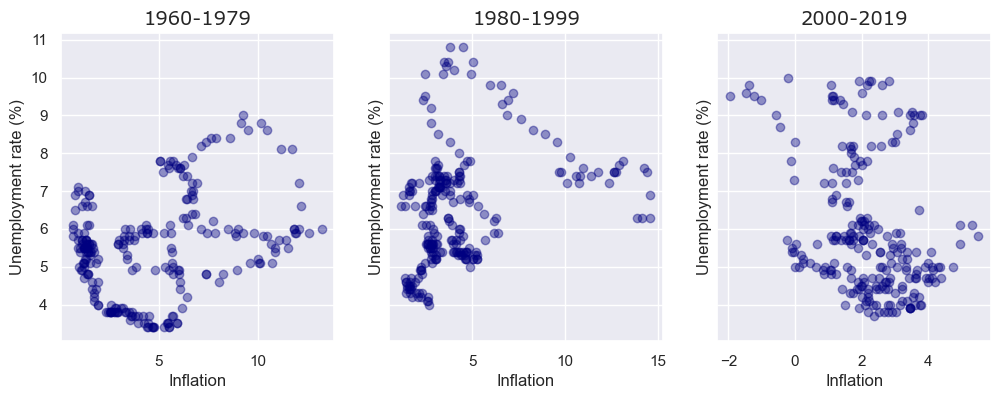

In [6]:
scatter_subs(data=fred, col_1="CPIAUCSL_diff", col_2="UNRATE", color="navy")

The presence of outliers may be attributable to macroeconomic regime shifts during the 1970s and 1980s. The elevated inflation observed in the 1970s reflects a period of sustained price pressures in the U.S. economy. In contrast, the clustering of lower inflation rates between 1980 and 1999 likely corresponds to the disinflationary period that followed the early 1980s recession—driven in part by the Federal Reserve’s aggressive monetary tightening in response to the preceding decade’s high inflation.

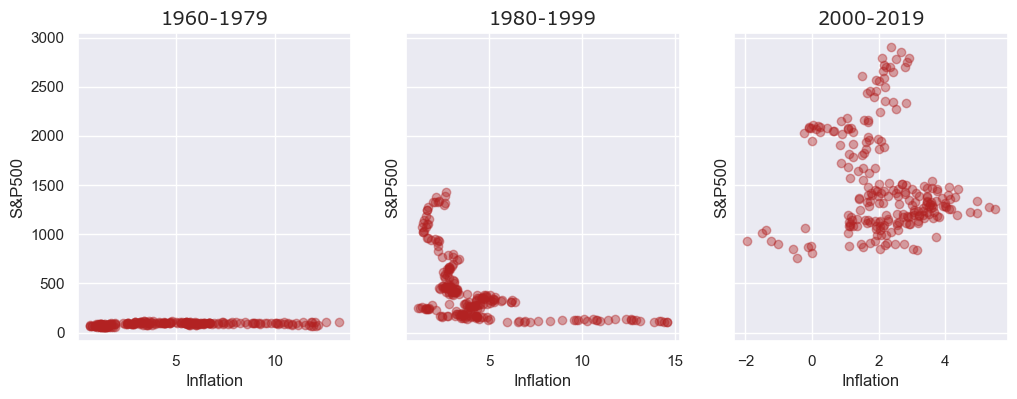

In [7]:
scatter_subs(data=fred, col_1="CPIAUCSL_diff", col_2="S&P 500", color="firebrick")

Across different subsamples of years, there does not appear to be any relationship between inflation and stock markets.

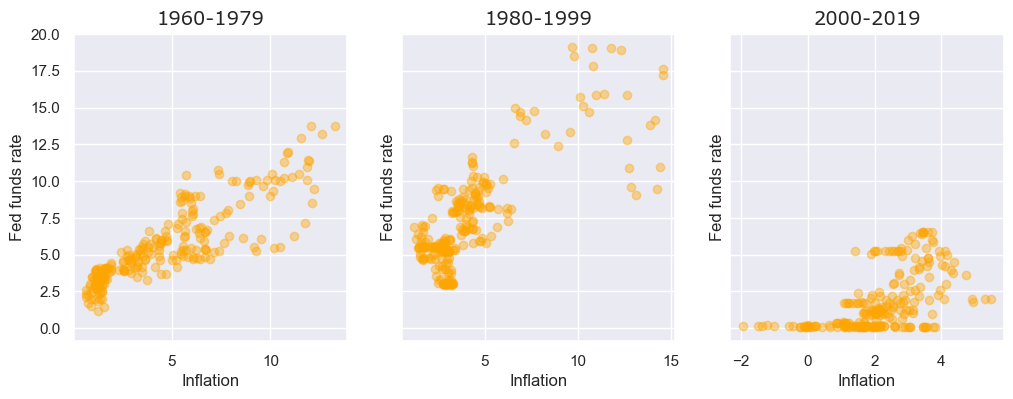

In [8]:
scatter_subs(data=fred, col_1="CPIAUCSL_diff", col_2="FEDFUNDS", color="orange")

In most intervals, the Fed funds rate has a positive, upward-sloping relationship with inflation. This makes sense as interest rates rise in response to inflation. Interest rates historically have been much higher than in recent times.

#### VAR: Traditional approach

In [9]:
from statsmodels.tsa.api import VAR

fred = pd.read_csv(resolve_fredmd_path())

fred = fred.drop(0)
fred["sasdate"] = pd.to_datetime(fred["sasdate"])
fred = fred.rename(columns={"sasdate": "date"})
fred = fred.set_index("date").sort_index()

# Stationarity
# First differences instead of percentage change
# It seems later on that Lasso had an issue fitting percentage change

for c in list(fred.columns.values):
    fred[c + "_diff"] = fred[c] - fred[c].shift(12)


My VAR model has 6 variables: Inflation, real personal income, unemployment rate, Fed Funds rate, a trade-weighted index of the US dollar with several major currencies and total housing starts, as well as 12 lags for each variable. $B$ represents a matrix of coefficients.

$$
\begin{bmatrix} \pi_{t} \\ rpi_{t} \\ unemp_{t} \\ fedrate_{t} \\ usd_{t} \\ houst_{t} \end{bmatrix} = \alpha_t + B_{t-1}\begin{bmatrix} \pi_{t-1} \\ rpi_{t-1} \\ unemp_{t-1} \\ fedrate_{t-1} \\ usd_{t-1} \\ houst_{t-1} \end{bmatrix} + \dots + B_{t-12}\begin{bmatrix} \pi_{t-12} \\ rpi_{t-12} \\ unemp_{t-12} \\ fedrate_{t-12} \\ usd_{t-12} \\ houst_{t-12} \end{bmatrix}+ \epsilon_t
$$


In [10]:
# Rename VAR variables

new_names = ["cpi", "rpi", "unemp", "fedrate", "usd", "houst"]
old_names = ["CPIAUCSL", "RPI", "UNRATE", "FEDFUNDS", "TWEXAFEGSMTHx", "HOUST"]

for n,o in dict(zip(new_names, old_names)).items():
    fred = fred.rename(columns={o:n})
    
new_names_diff = ["cpi_diff", "rpi_diff", "unemp_diff", "fedrate_diff", "usd_diff", "houst_diff"]
old_names_diff = ["CPIAUCSL_diff", "RPI_diff", "UNRATE_diff", "FEDFUNDS_diff", "TWEXAFEGSMTHx_diff", "HOUST_diff"]

for nd,od in dict(zip(new_names_diff, old_names_diff)).items():
    fred = fred.rename(columns={od:nd})
    
fred.head()

,rpi,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA_diff,DSERRG3M086SBEA_diff,CES0600000008_diff,CES2000000008_diff,CES3000000008_diff,UMCSENTx_diff,DTCOLNVHFNM_diff,DTCTHFNM_diff,INVEST_diff,VIXCLSx_diff
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2442.158,2293.2,17.272,292266.4261,18235.77392,22.0151,23.3984,22.2848,31.5847,18.6861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-02-01,2451.778,2301.5,17.452,294424.7425,18369.56308,22.4463,23.7142,22.4778,31.8164,18.7842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-03-01,2467.594,2318.5,17.617,293418.6704,18523.05762,22.7696,23.8577,22.5882,31.8164,19.1520,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-04-01,2483.671,2334.9,17.553,299322.8039,18534.46600,23.2547,24.2022,22.9191,32.3184,19.2746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-05-01,2498.026,2350.4,17.765,301364.3249,18679.66354,23.6050,24.4032,23.1398,32.4728,19.6670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def plot_vars(data, levels, color, leveltype):
    
    """
    Displays historical trends of VAR variables and remains robust if one of the
    expected aliases is missing from the current dataframe.
    """

    available_levels = [col for col in levels if col in data.columns]
    missing_levels = [col for col in levels if col not in data.columns]

    if missing_levels:
        print(f"Skipping missing columns in plot_vars: {missing_levels}")

    fig, ax = plt.subplots(1, len(available_levels), figsize=(16, 2.5), sharex=True)
    if len(available_levels) == 1:
        ax = [ax]

    for i, col in enumerate(available_levels):
        data[col].plot(ax=ax[i], legend=True, linewidth=1.0, color=color, sharex=True)

    fig.set_facecolor("floralwhite")
    fig.suptitle(
        f"Historical trends of VAR {leveltype} variables",
        fontsize=14,
        fontweight="bold",
        fontname="Verdana"
    )


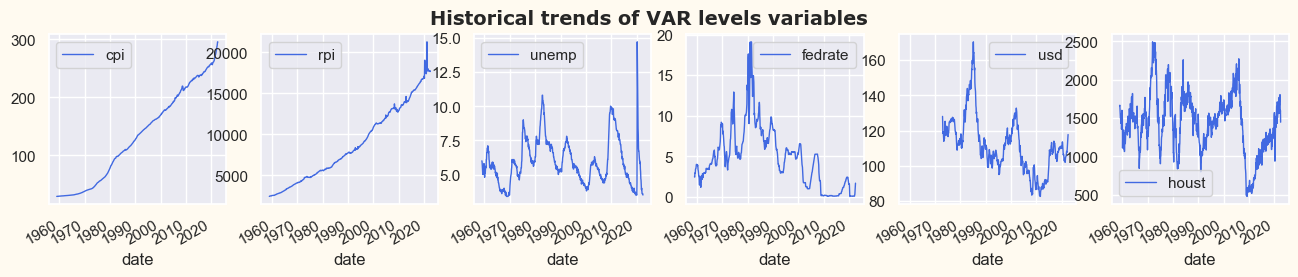

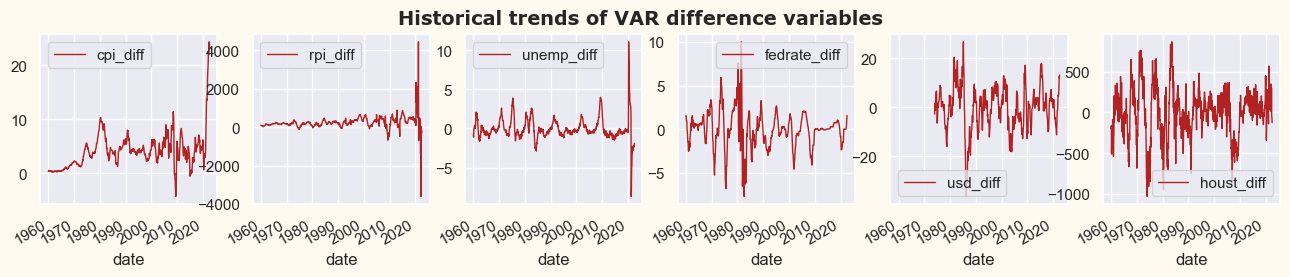

In [12]:
plot_vars(fred, levels=new_names, color="royalblue", leveltype="levels")
plot_vars(fred, levels=new_names_diff, color="firebrick", leveltype="difference")

Check for *stationarity*: Inflation and real personal income levels are clearly not stationary. I take the first differences in Fed Funds rate and trade-weighted USD index. Unemployment rate in levels looks stationary.

In [13]:

start_date = "2009-02-01"
end_date = "2019-01-01"

def var_create(columns, data):
    
    """
    Creates vector autoregressive model given data and list of selected variables
    Returns the MSE between forecasted and actual values
    Also returns the concatenated dataset for visualization purposes
    """
    
    data = data[columns]
    data = data.dropna(axis=0)
    data.index.to_period("M")
    
    # Split dataset and run VAR on the trained part
    data_train = data.loc["1973-01":"2009-01", :]
    var_train = VAR(data_train)
    results = var_train.fit(12)
    lag_order = results.k_ar
    forecasted = pd.DataFrame(results.forecast(data_train.values[-lag_order:], 120)) # Forecast 120 months
    
    # Rename forecasted columns
    forecasted_names = list(forecasted.columns.values)
    data_train_names = list(data_train.columns.values)
    
    var_dict = dict(zip(forecasted_names, data_train_names))
    
    for f,t in var_dict.items():
        forecasted = forecasted.rename(columns={f:t + "_fcast"})
        
    forecasted.index = pd.date_range(start=start_date, periods=forecasted.shape[0], freq="MS")
    forecasted.index.names = ["date"]
    
    # Parse together forecasted data with original dataset
    final_data = pd.merge(forecasted, data, left_index=True, right_index=True)
    final_data = final_data.sort_index(axis=0, ascending=True)
    final_data = pd.concat([data_train, final_data], sort=True, axis=0)
    final_data = final_data.sort_index(axis=0, ascending=True)
    
    var_mse = metrics.mean_squared_error(final_data.loc[start_date:end_date,"cpi_diff_fcast"], 
                           final_data.loc[start_date:end_date,"cpi_diff"])
    
    return var_mse, final_data


In [14]:
mse1, df1 = var_create(columns=["unemp", "cpi_diff", "fedrate_diff", 
                    "usd_diff", "rpi_diff", "houst"], data=fred)

print(f"The mean squared error between the forecasted and actual values is {mse1}")

The mean squared error between the forecasted and actual values is 7.292322954579065


/Users/atheeshkrishnan/AK/DEV/statmod/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [15]:
def plot_cpi(final_data, var_mse, approach):
    
    """
    Plots the actual values against forecast
    """
    
    fig, ax = plt.subplots(figsize=(14,6))
    colors = sns.color_palette("deep", 8)

    final_data["cpi_diff_fcast"].plot(ax=ax, legend=True, linewidth=2.5, linestyle="dashed")
    final_data["cpi_diff"].plot(ax=ax, legend=True, alpha=0.6, linestyle="solid")
    
    if approach=="traditional":
        ax.set_title("VAR in-sample forecast, traditional approach", fontsize=16, 
                     fontweight="bold", fontname="Verdana", loc="left")
    elif approach=="lasso":
        ax.set_title("VAR in-sample forecast, Lasso approach", fontsize=16, 
                     fontweight="bold", fontname="Verdana", loc="left")
    elif approach=="XGBoost":
        ax.set_title("VAR in-sample forecast, XGBoost approach", fontsize=16, 
                     fontweight="bold", fontname="Verdana", loc="left")
    else:
        ax.set_title("VAR in-sample forecast", fontsize=16, 
                     fontweight="bold", fontname="Verdana", loc="left")
    
    ax.set_ylabel("First differences", fontname="Verdana")
    ax.legend([f"VAR Forecast, MSE={var_mse}", "CPI Real Values"])
    

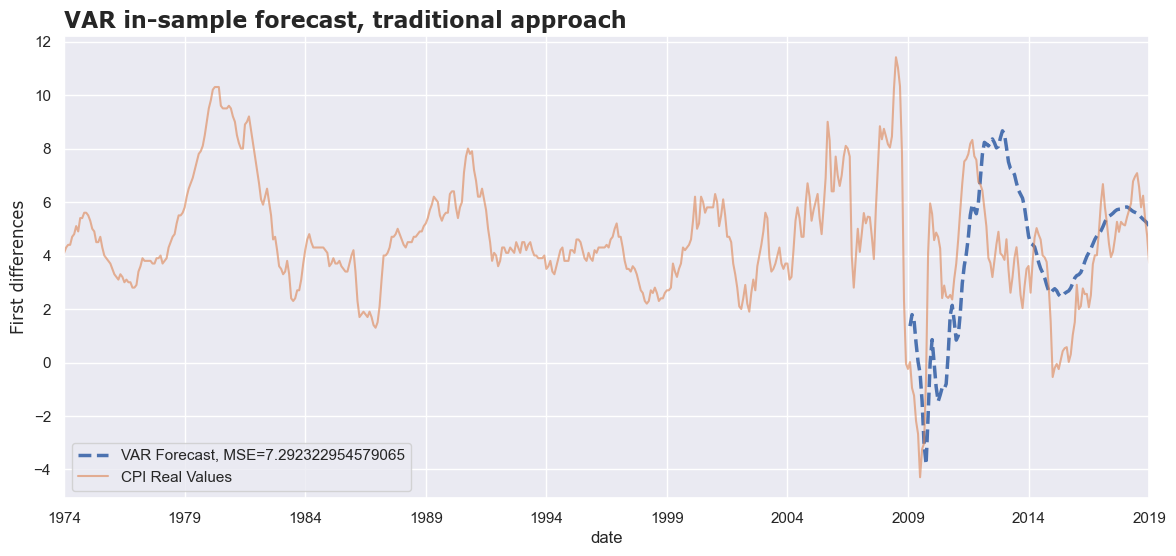

In [16]:
plot_cpi(final_data=df1, var_mse=mse1, approach="traditional")

The MSE is high, but the visualizations show that the VAR actually performs quite well over the forecast period.

#### VAR: Lasso approach

I now use Lasso to determine whether the features selected by VAR do a better job at predicting inflation. Does it select the same variables?

In [17]:
def timeseries_train_test_split(X, y, testsize):
    """
    This function splits the sample into a trained and test data
    """
    
    X_train = X.loc[:"2009-01-01"] # Until a particular date
    y_train = y.loc[:"2009-01-01"]
    X_test = X.loc["2009-01-01":]
    y_test = y.loc["2009-01-01":]
    
    return X_train, y_train, X_test, y_test

def train_test_plot(model, X_train, X_test):
    """
    This will plot the actual values of CPI against the one fitted by the model
    We train the model until 2009 and then use it from 2009 onwards on the test features dataset
    """
    fig, ax = plt.subplots(figsize=(12,4))
    colors = sns.color_palette("deep", 8)
    
    yvalues = pd.DataFrame(y_test)
    
    forecasted = list(model.predict(X_test)) # Use the model fit on features data from 2009 onwards
    df_fcast = pd.DataFrame({"date": list(yvalues.index), "cpi_fcast": forecasted})
    df_fcast = df_fcast.set_index("date")
    
    df = pd.merge(yvalues, df_fcast, left_index=True, right_index=True)

    df["cpi_fcast"].plot(ax=ax, legend=True, linewidth=2.5, linestyle="dashed", color="forestgreen") # CPI fitted
    df["cpi_diff"].plot(ax=ax, legend=True, linewidth=1.5, linestyle="solid", color="salmon") # Actual CPI values
    
    ax.set_title("CPI vs. Model's CPI")
    ax.set_ylabel("First differences")
    ax.legend(["Fitted CPI","Actual CPI"])


In [18]:
# Split into X and y
cpi_target = fred.dropna().cpi_diff
fred_features = fred.dropna().drop(["cpi_diff"], axis=1)

One thing to realize is that in time series data, Lasso performs the k-folds on a rolling basis, as the data is folded across time observations.

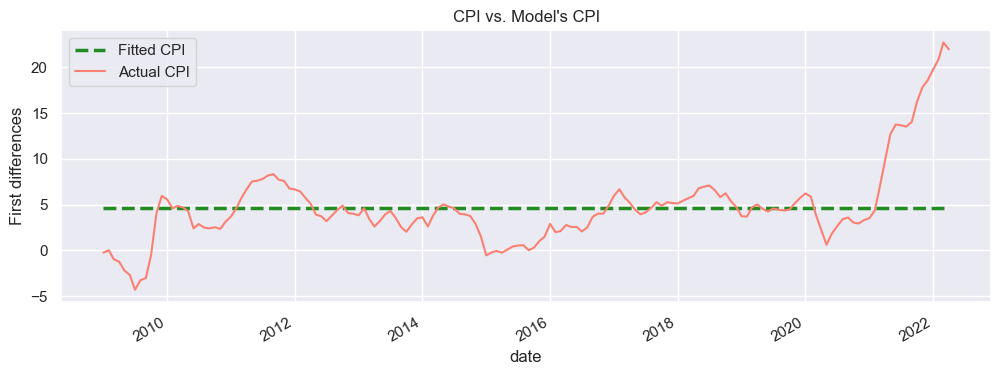

In [19]:
X_train, y_train, X_test, y_test = timeseries_train_test_split(X=fred_features, y=cpi_target, testsize=0.25)

lasso = linear_model.LassoCV(cv=model_selection.TimeSeriesSplit(n_splits=5), 
                             alphas=None, tol = 10000) 

fred_lasso = lasso.fit(X_train, y_train)
optimal_alpha = fred_lasso.alpha_

lasso2 = linear_model.Lasso(alpha=optimal_alpha)
lasso2.fit(X_train, y_train)

train_test_plot(lasso2, X_train, X_test) 

In [20]:
metrics.mean_squared_error(y_test, lasso2.predict(X_test))

18.894804953365377

The MSE is actually quite amazingly small, showing that the test data fitted into Lasso actually predicts CPI very well and closely fits with the actual values. Now for the feature selection:

In [21]:
lasso_coefs = pd.DataFrame({"features":list(X_train), "coef": lasso2.coef_})
lasso_coefs = lasso_coefs[lasso_coefs.coef != 0.0]
lasso_coefs.sort_values("coef", ascending=False)

,features,coef


I got the definitions from McCracken's website: https://s3.amazonaws.com/files.fred.stlouisfed.org/fred-md/Appendix_Tables_Update.pdf, but I rename the features below. The five features that are selected by Lasso are **CPI - All items less medical**, **CPI - Services**, **CPI - Commodities**, **CPI - All items less food**, **CPI - All items less shelter** and **CPI - Medical care**. This is strange, considering concerns of multicollinearity. It's almost like a univariate regression breaking down CPI into different parts. Nonetheless, I use them in the VAR to see how they perform. 

In [22]:
old_names2 = ["CUSR0000SA0L5_diff", "CUSR0000SAS_diff", 
              "CUSR0000SAC_diff", "CPIULFSL_diff", "CUSR0000SA0L2_diff"]

new_names2 = ["cpi_lessmed", "cpi_serv", "cpi_comm", "cpi_lessfd", "cpi_lessshelt"]

for n,o in dict(zip(new_names2, old_names2)).items():
    fred = fred.rename(columns={o:n})

new_names2 = new_names2 + ["cpi_diff"]
mse2, df2 = var_create(columns=new_names2, data=fred)
print(f"The mean squared error between the forecasted and actual values is {mse2}")

The mean squared error between the forecasted and actual values is 9.664203651446828


/Users/atheeshkrishnan/AK/DEV/statmod/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


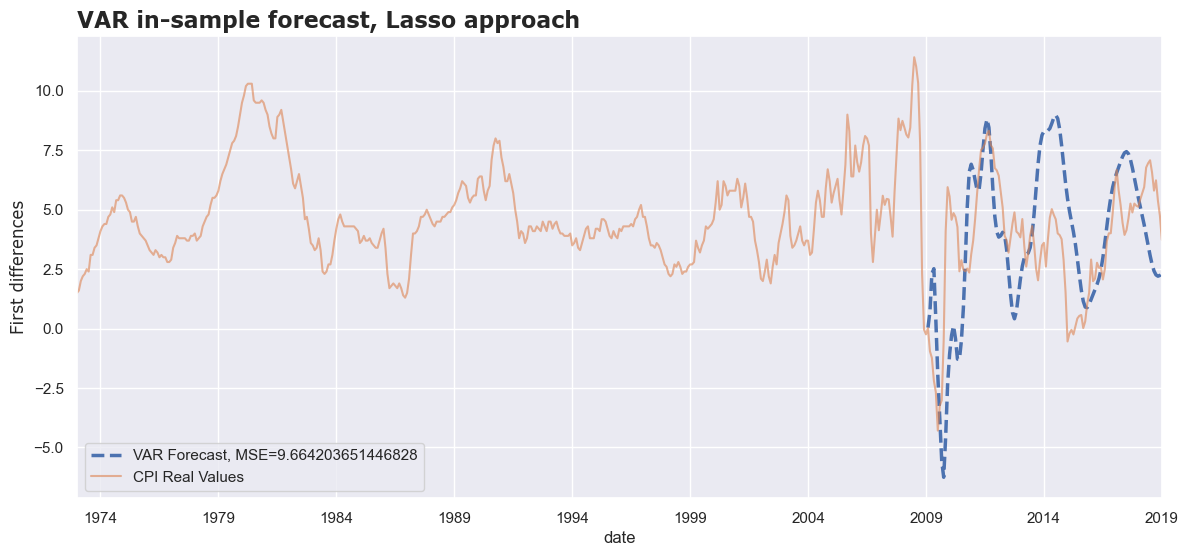

In [23]:
plot_cpi(final_data=df2, var_mse=mse2, approach="lasso")

The MSE is actually worse than that of the VAR using traditional approach. This shows that machine learning has its limits.

#### VAR: XGBoost approach

Next, I use XGBoost to select features for the VAR. It turns out that XGBoost and other tree-based models poorly handle trends in time series datasets. Ideally, I should restrict my dataset to stationary variables so that it doesn't 'read' variables that are trending upwards.

In [24]:
fred_features = fred_features[list(fred_features.filter(regex = "_diff"))] # Drop non-stationary variables 
X_train, y_train, X_test, y_test = timeseries_train_test_split(X=fred_features, y=cpi_target, testsize=0.25)


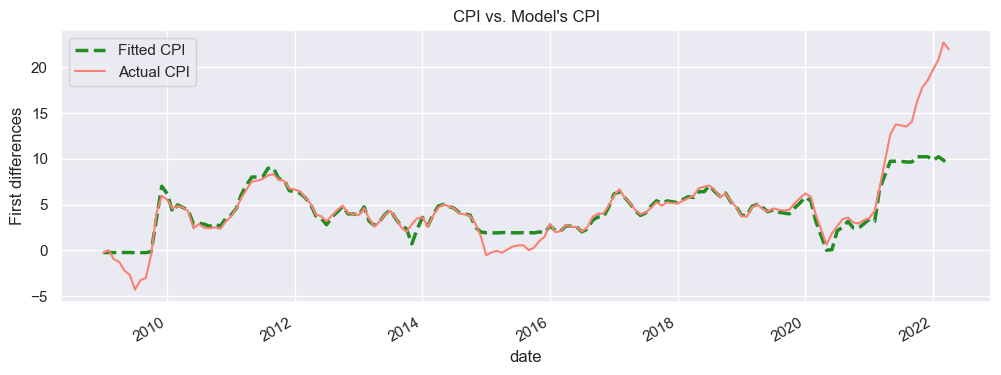

In [25]:
# Build XGBoost
# Normalize the features 
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

xgb = XGBRegressor()
xgb.fit(X_train_scaled, y_train)

X_test_scaled = scaler.transform(X_test)

train_test_plot(model=xgb, X_train=X_train_scaled, X_test=X_test_scaled)


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

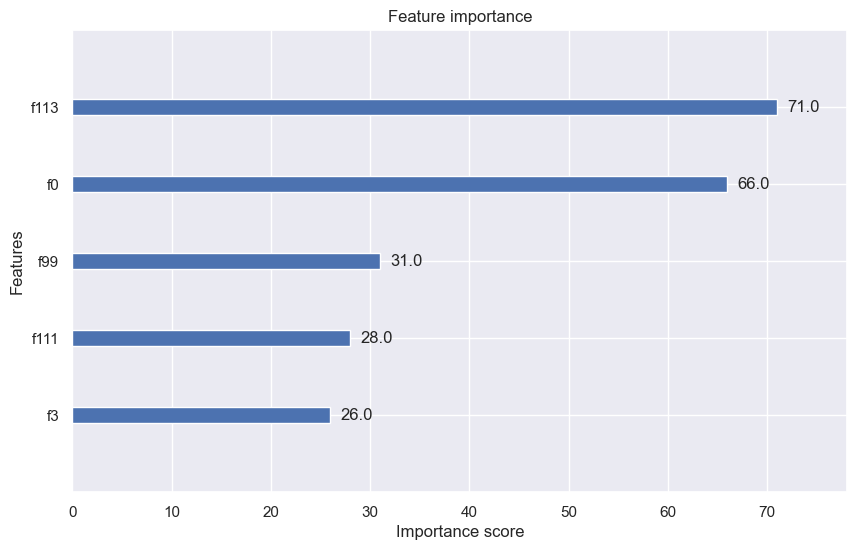

In [26]:
fig_xgb, ax_xgb = plt.subplots(figsize=(10,6))
plot_importance(xgb, max_num_features=5, ax=ax_xgb)

In [27]:
# Feature selection

for i, name in dict(zip(list(range(len(X_train.columns))), list(X_train.columns.values))).items():
    if i == 0:
        print(f"Feature {i} is {name}")
    elif i == 99:
        print(f"Feature {i} is {name}")
    elif i == 106:
        print(f"Feature {i} is {name}")
    elif i == 109:
        print(f"Feature {i} is {name}")
    elif i == 111:
        print(f"Feature {i} is {name}")


Feature 0 is rpi_diff
Feature 99 is WPSFD49207_diff
Feature 106 is CPITRNSL_diff
Feature 109 is CUSR0000SAD_diff
Feature 111 is CPIULFSL_diff


It turns out that **real personal income**, **PPI - Finished Goods**, **CPI - Transportation**, and **personal consumption expenditure (PCE)**, and **PCE - Non-durable goods** are the most important features for the XGBoost Regressor. I rename the variables for convenience below.

In [28]:
old_names3 = ["AMDMUOx", "cpi_lessmed", 
              "cpi_lessfd", "rpi", "PCEPI_diff"]

new_names3 = ["orders", "cpi_lessmed", "cpi_lessfd", "rpi", "pce_diff"]

for n,o in dict(zip(new_names3, old_names3)).items():
    fred = fred.rename(columns={o:n})

new_names3 = new_names3 + ["cpi_diff"]
mse3, df3 = var_create(columns=new_names3, data=fred)
print(f"The mean squared error between the forecasted and actual values is {mse3}")

The mean squared error between the forecasted and actual values is 68.534444166358


/Users/atheeshkrishnan/AK/DEV/statmod/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


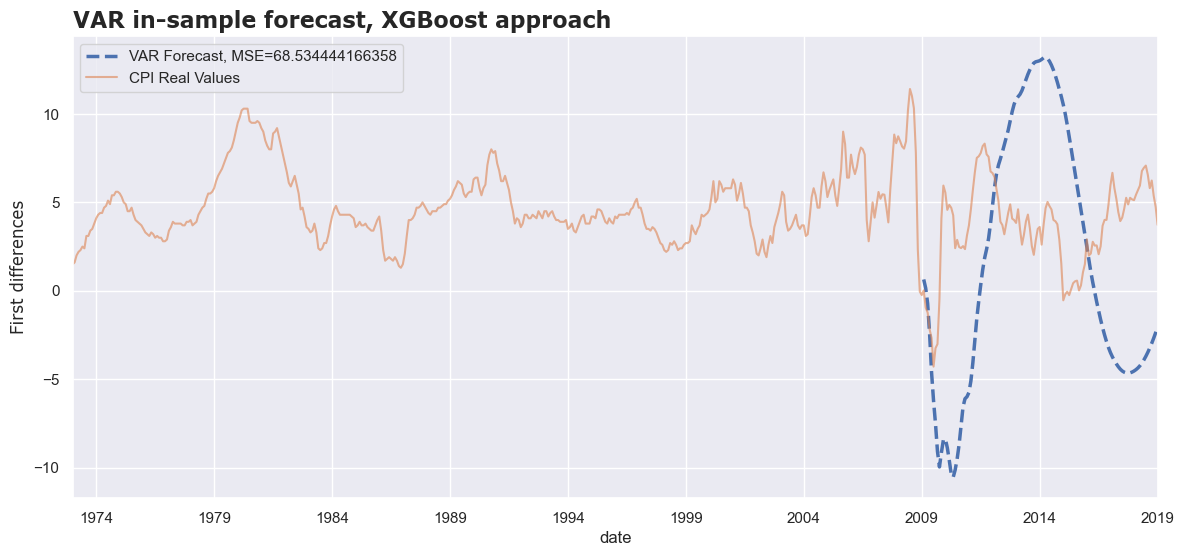

In [29]:
plot_cpi(final_data=df3, var_mse=mse3, approach="XGBoost")

The forecast is very poor. This highlights the challenges of using machine learning to select variables for forecasting.

#### Conclusions

From this exercise, it can be infereed that there's a fundamental difference between prediction/fit and forecasting. While the historical prediction of a model might be very good and training the model on a test dataset might yield low MSEs, forecasting with those same features is tricky. Because variables in VAR interact endogenously with each other, there's much uncertainty with how the selected features will trend over time. When it comes to forecasting, one needs to decide which variables are the most important and not just rely solely on fit. A summary of the MSEs between actual and forecasted values for each approach is provided below. 

Text(0, 0.5, 'MSE')

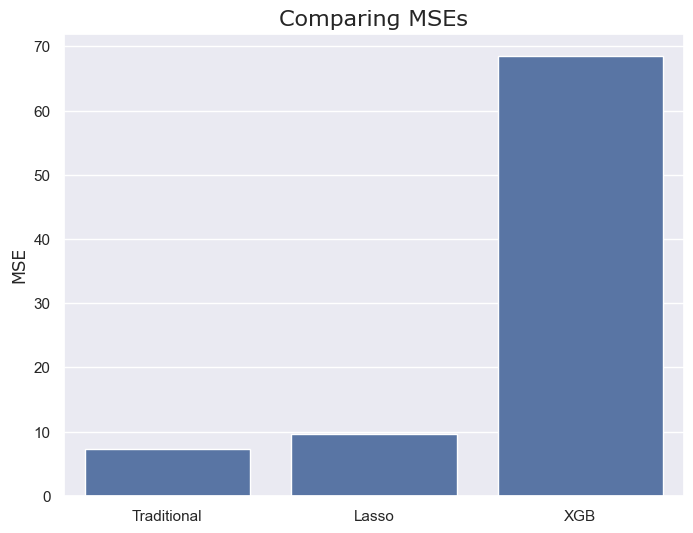

In [30]:
fig, ax = plt.subplots(figsize=(8,6))

ax = sns.barplot(x = ["Traditional", "Lasso", "XGB"], y = [mse1, mse2, mse3])
ax.set_title("Comparing MSEs", fontsize=16, fontname="Verdana")
ax.set_ylabel("MSE", fontname="Verdana")

After this exercise, I find that the traditional approach is much better than machine learning approaches. In terms of policy implications, there is still value in looking to economic theory (such as the Phillips Curve) to assist in forecasting.

### VAR: PCA feature-selection approach
This section adds a fourth model branch to the existing comparison framework.

**Objective:** select predictors using PCA loading structure (instead of Lasso/XGBoost), then run the same VAR forecasting function used elsewhere.

**Design principles:**
- Keep the downstream model fixed (`VAR`) for comparability.
- Use the same transformed/stationarity-oriented feature set (`*_diff`) used in the ML branches.
- Select a compact set of original variables by ranking their weighted PCA loading contributions.


In [31]:
# --- PCA-based feature selection for VAR ---
from pathlib import Path

# Resolve dataset path robustly for different notebook launch locations.
candidate_paths = [
    Path.cwd() / 'data' / 'fredmd.csv',
    Path.cwd() / 'fredmd.csv',
    Path.cwd().parent / 'data' / 'fredmd.csv',
]
fred_path = next((p for p in candidate_paths if p.exists()), None)
if fred_path is None:
    raise FileNotFoundError('Could not locate fredmd.csv. Expected one of: data/fredmd.csv or fredmd.csv')

print('Using FRED-MD file:', fred_path)

# Rebuild a clean modeling frame to avoid accidental carry-over from prior renaming steps.
fred_pca = pd.read_csv(fred_path)
fred_pca = fred_pca.drop(0)
fred_pca['sasdate'] = pd.to_datetime(fred_pca['sasdate'])
fred_pca = fred_pca.rename(columns={'sasdate': 'date'}).set_index('date').sort_index()

# Annual differences (same transform style used in the modeling sections above).
for c in list(fred_pca.columns.values):
    fred_pca[c + '_diff'] = fred_pca[c] - fred_pca[c].shift(12)

# Rename core benchmark variables so var_create remains directly usable.
old_names = ['CPIAUCSL', 'RPI', 'UNRATE', 'FEDFUNDS', 'TWEXAFEGSMTHx', 'HOUST']
new_names = ['cpi', 'rpi', 'unemp', 'fedrate', 'usd', 'houst']
for o, n in dict(zip(old_names, new_names)).items():
    if o in fred_pca.columns:
        fred_pca = fred_pca.rename(columns={o: n})

old_names_diff = ['CPIAUCSL_diff', 'RPI_diff', 'UNRATE_diff', 'FEDFUNDS_diff', 'TWEXAFEGSMTHx_diff', 'HOUST_diff']
new_names_diff = ['cpi_diff', 'rpi_diff', 'unemp_diff', 'fedrate_diff', 'usd_diff', 'houst_diff']
for od, nd in dict(zip(old_names_diff, new_names_diff)).items():
    if od in fred_pca.columns:
        fred_pca = fred_pca.rename(columns={od: nd})

# Candidate predictors: transformed macro panel excluding CPI target.
model_df = fred_pca.dropna().copy()
y = model_df['cpi_diff']
X = model_df.drop(columns=['cpi_diff'])
X = X.loc[:, X.columns.str.endswith('_diff')]  # Stationarity-oriented feature set

print('PCA candidate feature matrix shape:', X.shape)
print('Target shape:', y.shape)


Using FRED-MD file: /Users/atheeshkrishnan/AK/DEV/econometric-forecasting/varifmod/data/fredmd.csv
PCA candidate feature matrix shape: (349, 126)
Target shape: (349,)


#### PCA selection logic
PCA is not a direct feature selector like Lasso. In this notebook it is used as a **feature-ranking mechanism**:

1. Standardize the training predictors.
2. Fit PCA only on the training matrix to avoid leakage.
3. Inspect both the scree plot and cumulative explained variance.
4. Rank original variables using weighted absolute loadings.
5. Select the top-ranked original variables and pass them into the same `VAR` pipeline.

This keeps the experiment controlled: PCA changes only the **selection logic**, while the downstream forecasting model remains unchanged.


In [32]:
# Train/test split aligned with the existing notebook logic.
X_train, y_train, X_test, y_test = timeseries_train_test_split(
    X=X,
    y=y,
    testsize=0.25,
)

print('Training feature matrix:', X_train.shape)
print('Test feature matrix:', X_test.shape)
print('Training target shape:', y_train.shape)


Training feature matrix: (192, 126)
Test feature matrix: (158, 126)
Training target shape: (192,)


In [33]:
# Standardize predictors before PCA so loading magnitudes are comparable.
scaler_pca = preprocessing.StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)

print('Scaled training matrix shape:', X_train_scaled.shape)


Scaled training matrix shape: (192, 126)


In [34]:
# Fit PCA on the training predictors only.
from sklearn.decomposition import PCA

pca_full = PCA(svd_solver='full')
pca_full.fit(X_train_scaled)

full_exp_var = pca_full.explained_variance_ratio_
full_cum_exp_var = np.cumsum(full_exp_var)

pca_full_df = pd.DataFrame({
    'component': np.arange(1, len(full_exp_var) + 1),
    'explained_variance_ratio': full_exp_var,
    'cumulative_explained_variance': full_cum_exp_var,
})

display(pca_full_df.head(15))


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.343691,0.343691
1,2,0.164077,0.507768
2,3,0.088399,0.596167
3,4,0.065974,0.662140
4,5,0.052936,0.715076
5,6,0.044115,0.759191
6,7,0.033637,0.792828
7,8,0.028523,0.821351
8,9,0.020569,0.841920
9,10,0.019798,0.861718


#### Scree plot vs cumulative explained variance

- A **scree plot** shows the explained variance (or eigenvalue) of each principal component individually.
- A **cumulative explained variance plot** shows how much total variance is explained as components are added.

The cumulative plot in the notebook is useful for choosing a retention threshold, but it is **not** the same as a scree plot. Both are included below because they answer slightly different questions.


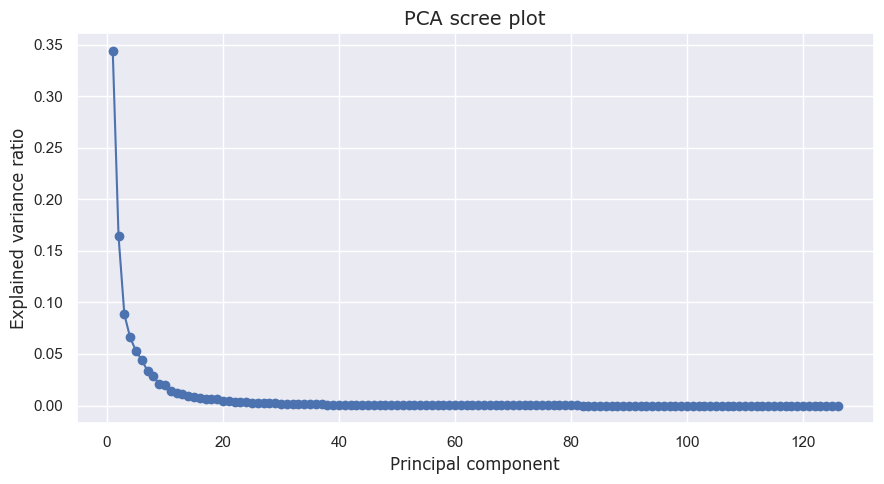

In [35]:
# Scree plot: variance explained by each component individually.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pca_full_df['component'], pca_full_df['explained_variance_ratio'], marker='o')
ax.set_title('PCA scree plot', fontsize=14, fontname='Verdana')
ax.set_xlabel('Principal component', fontname='Verdana')
ax.set_ylabel('Explained variance ratio', fontname='Verdana')
plt.tight_layout()
plt.show()


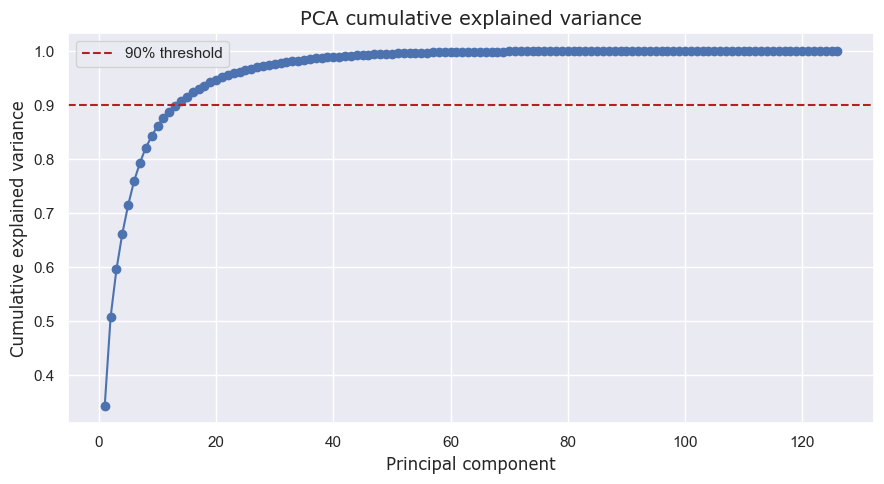

In [36]:
# Cumulative explained variance plot: useful for choosing how many PCs to retain.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pca_full_df['component'], pca_full_df['cumulative_explained_variance'], marker='o')
ax.axhline(0.90, color='firebrick', linestyle='--', label='90% threshold')
ax.set_title('PCA cumulative explained variance', fontsize=14, fontname='Verdana')
ax.set_xlabel('Principal component', fontname='Verdana')
ax.set_ylabel('Cumulative explained variance', fontname='Verdana')
ax.legend()
plt.tight_layout()
plt.show()


In [43]:
# Retain enough components to explain ~90% of training-feature variance.
pca_fs = PCA(n_components=0.95, svd_solver='full')
pca_fs.fit(X_train_scaled)

n_comp = pca_fs.n_components_
exp_var = pca_fs.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

pca_variance_df = pd.DataFrame({
    'component': np.arange(1, n_comp + 1),
    'explained_variance_ratio': exp_var,
    'cumulative_explained_variance': cum_exp_var,
})

print('PCA retained components:', n_comp)
display(pca_variance_df)


PCA retained components: 21


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.343691,0.343691
1,2,0.164077,0.507768
2,3,0.088399,0.596167
3,4,0.065974,0.662140
4,5,0.052936,0.715076
5,6,0.044115,0.759191
6,7,0.033637,0.792828
7,8,0.028523,0.821351
8,9,0.020569,0.841920
9,10,0.019798,0.861718


#### Ranking original variables from PCA loadings
The ranking step uses the retained loading matrix:

$$
\text{score}_j = \sum_{k=1}^{K} |\ell_{jk}|\, w_k
$$

where:

- \(\ell_{jk}\) is the loading of feature \(j\) on component \(k\),
- \(w_k\) is the explained-variance ratio of component \(k\).

This favors variables that contribute strongly across the most informative principal components.


In [44]:
# Build loading matrix: rows = original variables, columns = retained components.
loadings = pca_fs.components_.T
loading_cols = [f'PC{i}' for i in range(1, n_comp + 1)]
loading_df = pd.DataFrame(loadings, index=X_train.columns, columns=loading_cols)

display(loading_df.head(10))


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21
rpi_diff,-0.094540,0.027098,0.083046,-0.032530,-0.166138,-0.066795,0.116548,-0.140696,-0.055800,-0.062809,...,-0.065724,0.087543,-0.140610,-0.053101,0.005503,0.041022,-0.175847,0.055924,0.063273,-0.118184
W875RX1_diff,-0.111152,0.003518,0.078366,-0.034825,-0.152978,-0.053014,0.099524,-0.126700,-0.059480,-0.040500,...,-0.052509,0.045702,-0.156151,-0.018406,0.042145,-0.047931,-0.106542,0.039111,0.026645,-0.112772
DPCERA3M086SBEA_diff,-0.097648,-0.047989,-0.080822,-0.046485,-0.154477,-0.043149,0.121182,-0.075919,-0.094272,-0.108875,...,0.052055,0.102171,-0.076157,-0.038707,0.016142,0.035995,-0.050694,-0.049642,0.038654,0.001574
CMRMTSPLx_diff,-0.134303,-0.042163,-0.082052,0.002628,-0.070240,-0.040433,-0.022380,0.029233,0.018579,-0.007543,...,-0.025298,0.016317,0.099122,0.042335,-0.001723,0.016084,-0.014327,-0.005983,0.010553,0.090201
RETAILx_diff,-0.111321,0.014346,-0.147581,-0.021309,-0.031666,-0.037839,0.089928,-0.005556,0.074223,-0.061660,...,-0.001978,0.032798,0.012127,0.047951,0.025425,0.034713,0.084253,-0.066302,0.004146,0.025953
INDPRO_diff,-0.140207,-0.018463,-0.025309,0.002844,-0.074611,-0.063481,-0.071818,0.051486,-0.071046,0.057562,...,0.020142,0.056636,0.045284,-0.002048,-0.002051,0.004619,-0.003555,0.065443,-0.016321,-0.035902
IPFPNSS_diff,-0.143443,-0.023266,-0.013802,-0.027412,-0.054848,-0.045157,-0.044866,-0.006852,-0.041516,0.092466,...,-0.011111,0.034166,0.069668,-0.015827,0.013640,0.010613,-0.006395,0.044565,-0.074974,-0.018269
IPFINAL_diff,-0.141984,-0.015179,0.001621,-0.035336,-0.068673,-0.040643,-0.048847,-0.007008,-0.028728,0.092420,...,-0.007898,0.041097,0.069087,-0.004914,0.005403,0.032025,-0.018014,0.030132,-0.099383,-0.016934
IPCONGD_diff,-0.120273,-0.095053,-0.047205,-0.018598,-0.026293,0.005273,0.003592,0.048210,-0.025768,0.163007,...,0.017215,0.045878,0.077766,-0.079571,0.014713,-0.027249,-0.046216,0.009355,-0.168150,-0.076039
IPDCONGD_diff,-0.101387,-0.102938,-0.105515,0.019707,-0.043290,-0.062857,-0.064919,0.086510,-0.034802,0.099643,...,-0.072637,-0.036046,-0.021839,0.028638,0.061027,-0.049670,-0.054658,0.034214,-0.092483,-0.065054


In [45]:
# Weight absolute loadings by explained-variance importance to rank original features.
feature_scores = (loading_df.abs().values * exp_var).sum(axis=1)
score_df = (
    pd.DataFrame({'feature': X_train.columns, 'pca_score': feature_scores})
    .sort_values('pca_score', ascending=False)
    .reset_index(drop=True)
)

print('Top PCA-ranked features:')
display(score_df.head(10))


Top PCA-ranked features:


,feature,pca_score
0,IPDCONGD_diff,0.079933
1,DPCERA3M086SBEA_diff,0.078456
2,AWOTMAN_diff,0.077243
3,NDMANEMP_diff,0.076977
4,CES2000000008_diff,0.076959
5,UMCSENTx_diff,0.076355
6,T10YFFM_diff,0.076020
7,S&P div yield_diff,0.075627
8,BOGMBASE_diff,0.075250
9,rpi_diff,0.075160


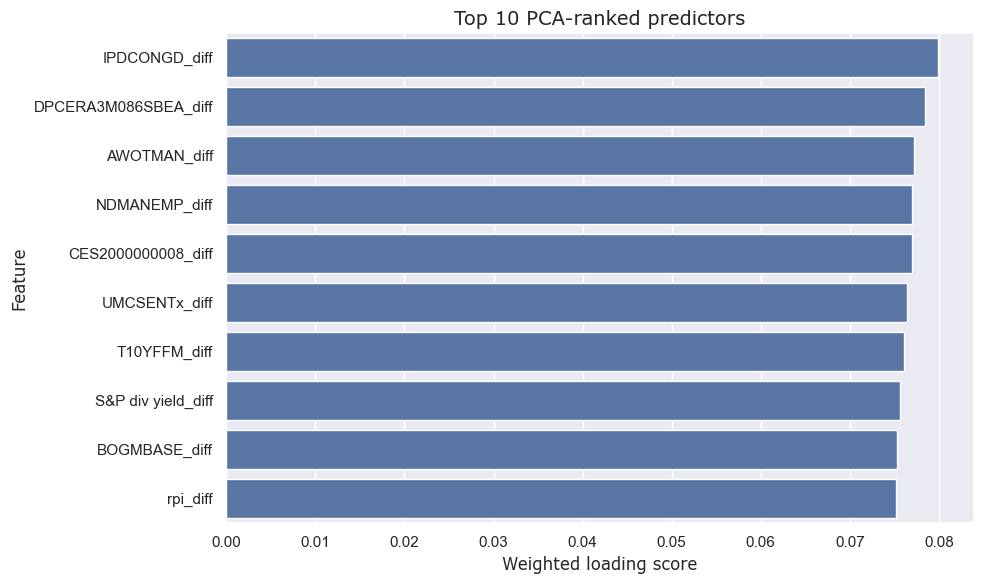

In [46]:
# Simple plot of top-ranked PCA features for interpretability.
fig, ax = plt.subplots(figsize=(10, 6))
top_scores = score_df.head(10)
sns.barplot(data=top_scores, x='pca_score', y='feature', ax=ax)
ax.set_title('Top 10 PCA-ranked predictors', fontsize=14, fontname='Verdana')
ax.set_xlabel('Weighted loading score', fontname='Verdana')
ax.set_ylabel('Feature', fontname='Verdana')
plt.tight_layout()
plt.show()


#### PCA-selected VAR branch
To keep this branch comparable to Lasso and XGBoost:

- use a compact predictor set,
- keep the downstream `VAR` unchanged,
- evaluate with the same `MSE` criterion.

The notebook selects the top 5 PCA-ranked variables and then reuses `var_create(...)`.


PCA-selected VAR predictors: ['IPDCONGD_diff', 'DPCERA3M086SBEA_diff', 'AWOTMAN_diff', 'NDMANEMP_diff', 'CES2000000008_diff']
PCA-selected VAR MSE: 16.427416762947228


/Users/atheeshkrishnan/AK/DEV/statmod/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


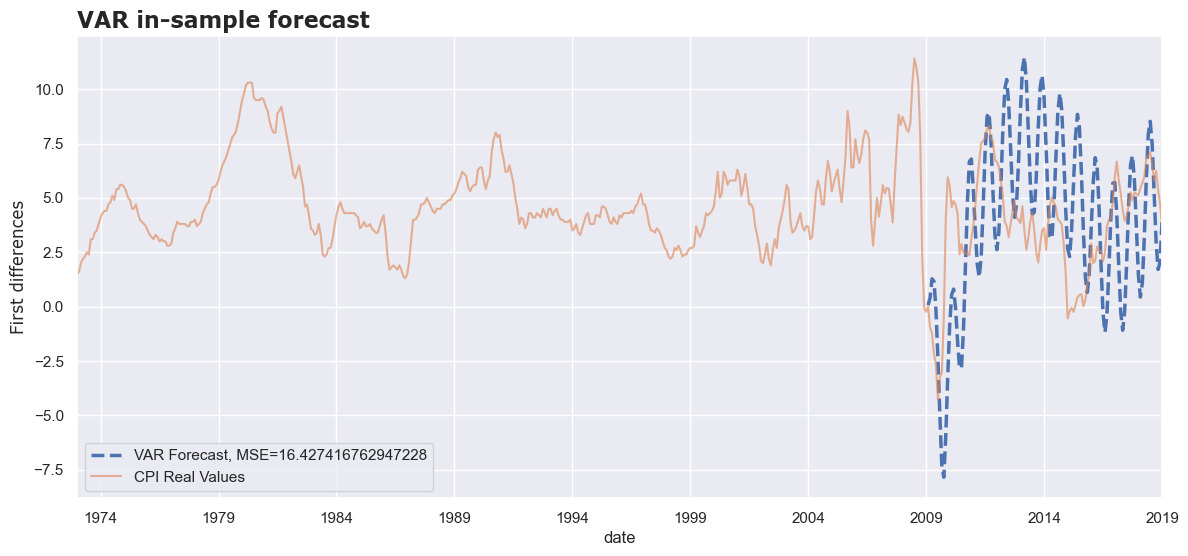

In [47]:
# Select a compact number of PCA-ranked predictors and run the same VAR engine.
n_select = 5
pca_selected_features = score_df['feature'].head(n_select).tolist()
pca_var_cols = pca_selected_features + ['cpi_diff']
pca_var_cols = [c for c in pca_var_cols if c in fred_pca.columns]

print('PCA-selected VAR predictors:', pca_selected_features)

mse4, df4 = var_create(columns=pca_var_cols, data=fred_pca)
print(f'PCA-selected VAR MSE: {mse4}')
plot_cpi(final_data=df4, var_mse=mse4, approach='pca')


### Four-way model comparison
This compares all branches under the same downstream forecasting setup:

- Traditional
- Lasso-selected
- XGBoost-selected
- PCA-selected


Model comparison (lower MSE is better):


,Approach,MSE
0,Traditional,7.292323
1,Lasso,9.664204
2,PCA,16.427417
3,XGBoost,68.534444


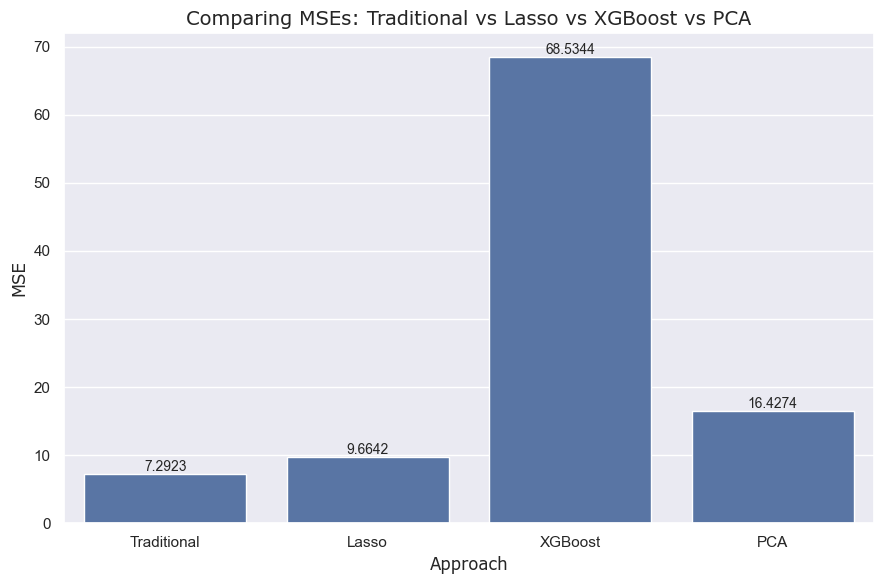

In [48]:
comparison_df = pd.DataFrame({
    'Approach': ['Traditional', 'Lasso', 'XGBoost', 'PCA'],
    'MSE': [mse1, mse2, mse3, mse4],
})

print('Model comparison (lower MSE is better):')
display(comparison_df.sort_values('MSE').reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=comparison_df,
    x='Approach',
    y='MSE',
    ax=ax,
    order=['Traditional', 'Lasso', 'XGBoost', 'PCA'],
)
ax.set_title('Comparing MSEs: Traditional vs Lasso vs XGBoost vs PCA', fontsize=14, fontname='Verdana')
ax.set_ylabel('MSE', fontname='Verdana')
ax.set_xlabel('Approach', fontname='Verdana')
for i, row in comparison_df.set_index('Approach').reindex(['Traditional', 'Lasso', 'XGBoost', 'PCA']).reset_index().iterrows():
    ax.text(i, row['MSE'], f"{row['MSE']:.4f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


### Interpretation prompt
When reviewing results, focus on:

1. Whether PCA-selected predictors improve MSE relative to Lasso/XGBoost.
2. Whether PCA ranking favors broad macro factors or CPI-adjacent variables.
3. Whether dimensional compression helps the downstream VAR remain stable without over-selecting noisy predictors.
